In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner

In [25]:
import pickle
import dill
import os
import pandas as pd

In [26]:
TESS_offset = 2457000
petigura_offset = 2454833


In [63]:
file_name = 'jnkep_initial_fit_data_tree-11_accept-90_hessian_emax-0.5.pkl'
file_name = 'data/jnkep_initial_fit_data.pkl'

with open(file_name, 'rb') as f:
    data = pickle.load(f)

popt = data['popt']
param_bounds = data['param_bounds']
jttv = data['jttv']

sample: 100%|█| 1000/1000 [00:00<00:00, 2094.48it/s, 3 steps of size 4.86e-01. acc



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      0.78      0.45      0.74      0.03      1.39    161.00      1.00
     lnvar     -1.08      0.45     -1.10     -1.80     -0.39    158.97      1.00

Number of divergences: 0


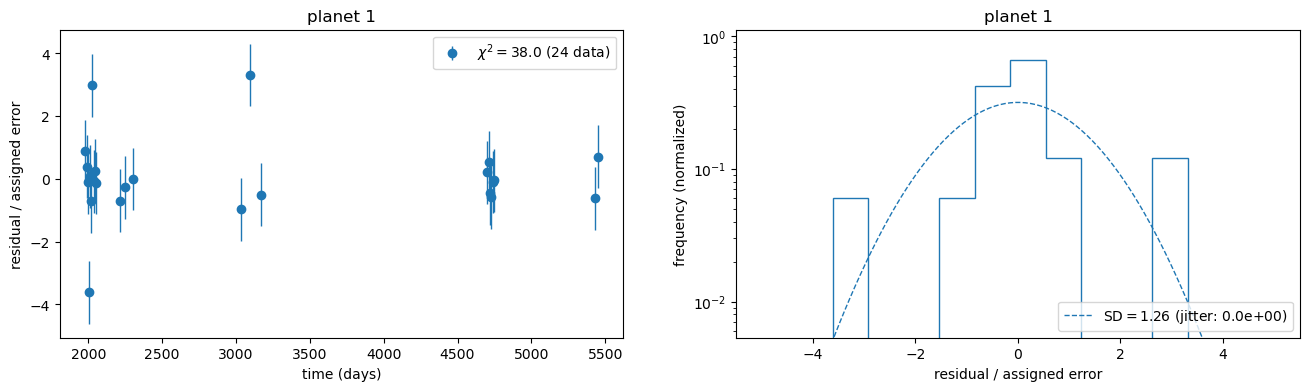

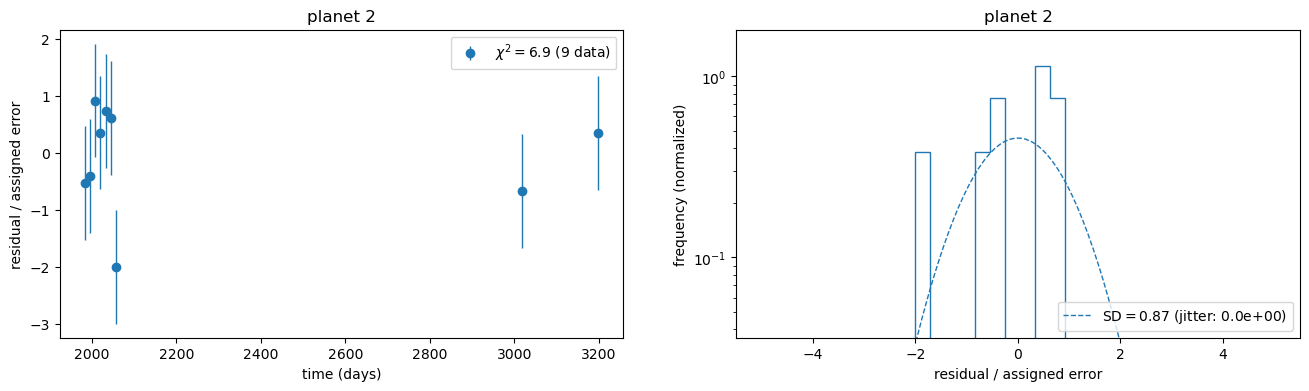

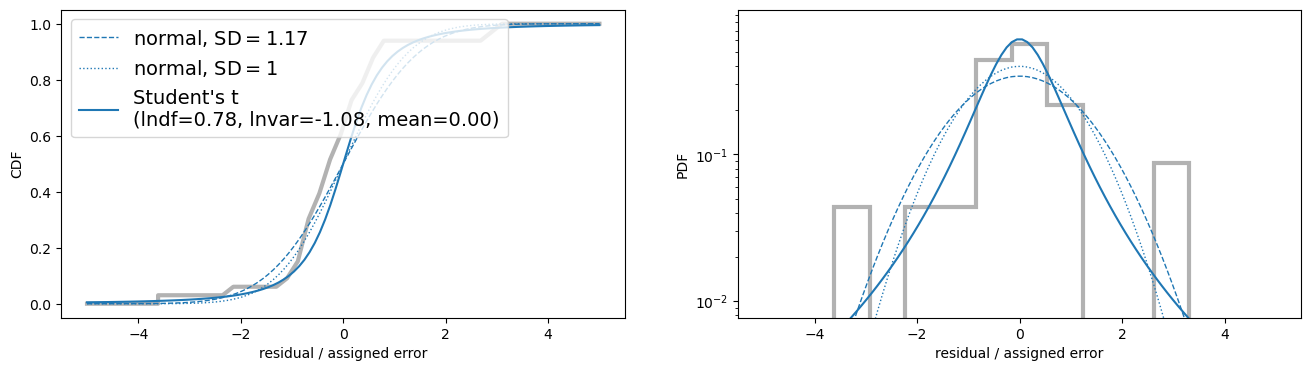

In [64]:
pdic_normal, pdic_student = jttv.check_residuals(popt)
plt.show()

# transit times

In [65]:
file_path = 'data/ttv_results.txt'  # Replace with your file path
with open(file_path, 'r') as file:
    # Read the entire content of the file
    content = file.read()
    # Print the content
    print(content)

Planet_num Index Tc Tc_err Source Instrument
1 -6 1980.38403000 0.00044000 Narita2015 K2
1 -5 1988.30421000 0.00061000 Narita2015 K2
1 -4 1996.22197000 0.00048000 Narita2015 K2
1 -3 2004.13851000 0.00066000 Narita2015 K2
1 -2 2012.06161000 0.00042000 Narita2015 K2
1 -1 2019.97953000 0.00066000 Narita2015 K2
1 0 2027.90124000 0.00068000 Narita2015 K2
1 1 2035.82024000 0.00041000 Narita2015 K2
1 2 2043.73925000 0.00054000 Narita2015 K2
1 3 2051.65861000 0.00059000 Narita2015 K2
1 24 2218.00410000 0.00220000 Petigura2020 FLWO
1 28 2249.69550000 0.00140000 Petigura2020 TRAPPIST
1 35 2305.15050000 0.00140000 Petigura2020 MuSCAT
1 127 3033.86040000 0.00090000 Petigura2020 Spitzer
1 135 3097.25020000 0.00240000 Petigura2020 LCO
1 144 3168.53680000 0.00140000 Petigura2020 Spitzer
1 337 4697.28902908 0.00438418 TESS TESS
1 339 4713.12734384 0.00283688 TESS TESS
1 340 4721.04182988 0.00301275 TESS TESS
1 341 4728.95965259 0.00299255 TESS TESS
1 342 4736.88081197 0.00414184 TESS TESS
1 343 4744.7

In [66]:
filter_times = True

if filter_times:
    times_to_remove = [3097.250200, 2004.138510, 2027.901240]
    
    # Remove rows
    d_filtered = d[~d['Tc'].isin(times_to_remove)]
    
    d = d_filtered


# 1000 burn in 1000 samples

In [67]:
# file_name = 'jnkep_fit_k2-19_nburn-1000_nsteps-1000_emax=0.5.pkl'
file_name  = 'data/jnkep_fit_k2-19_nburn-1000_nsteps-1000_accept-90_tree-11_hessian_emax-0.5.pkl'
# file_name = 'jnkep_fit_k2-19_nburn-1000_nsteps-1000_accept-90_tree-11_hessian_emax-0.5.pkl'
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [68]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.45      0.06      0.45      0.35      0.53    416.45      1.01
 ecosw_scaled[1]      0.47      0.05      0.48      0.40      0.54    411.27      1.01
 esinw_scaled[0]      0.45      0.09      0.46      0.30      0.59    375.05      1.02
 esinw_scaled[1]      0.40      0.08      0.42      0.28      0.52    370.70      1.02
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    516.45      1.01
period_scaled[1]      0.51      0.01      0.51      0.50      0.52    553.37      1.00
 pmass_scaled[0]      0.11      0.01      0.11      0.10      0.12    391.35      1.01
 pmass_scaled[1]      0.04      0.00      0.04      0.03      0.04    700.66      1.01
   tic_scaled[0]      0.50      0.00      0.50      0.49      0.50   1095.93      1.00
   tic_scaled[1]      0.51      0.01      0.51      0.49      0.53   1017.84      1.00

Number of divergences: 5


In [69]:
print(mcmc.__dict__.keys())

dict_keys(['sampler', '_sample_field', '_default_fields', 'num_warmup', 'num_samples', 'num_chains', 'thinning', 'postprocess_fn', 'chain_method', 'progress_bar', '_jit_model_args', '_states', '_states_flat', '_last_state', '_warmup_state', '_init_state_cache', '_cache', '_collection_params', '_args', '_kwargs'])


In [70]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})

# Example: summary for 'pmass'
import numpy as np
print("pmass mean:", np.mean(posterior_samples['pmass']))
print("pmass 95% CI:", np.percentile(posterior_samples['pmass'], [2.5, 97.5]))

{'ecc': (4000, 2), 'ecosw': (4000, 2), 'ecosw_scaled': (4000, 2), 'ediff': (4000,), 'esinw': (4000, 2), 'esinw_scaled': (4000, 2), 'period': (4000, 2), 'period_scaled': (4000, 2), 'pmass': (4000, 2), 'pmass_scaled': (4000, 2), 'tcmodel': (4000, 33), 'tic': (4000, 2), 'tic_scaled': (4000, 2)}
pmass mean: 7.254037463838835e-05
pmass 95% CI: [3.54681888e-05 1.20817084e-04]


## Plot models drawn from posteriors 

In [71]:
samples = mcmc.get_samples()

In [72]:
means, stds = jttv.sample_means_and_stds(samples, truncate=False)

In [37]:
# print(samples_1000)

In [38]:
import json

# Convert all arrays to regular lists
fit_data = {
    "jnkep_mcmc_times": {
        "b": means[0].tolist(),
        "c": means[1].tolist()
    },
    "jnkep_mcmc_times_err": {
        "b": stds[0].tolist(),
        "c": stds[1].tolist()
    }
}

# Save to JSON
with open("data/jnkep_mcmc_data.json", "w") as f:
    json.dump(fit_data, f, indent=4)

print("Data saved successfully.")

Data saved successfully.


<Figure size 1920x1440 with 0 Axes>

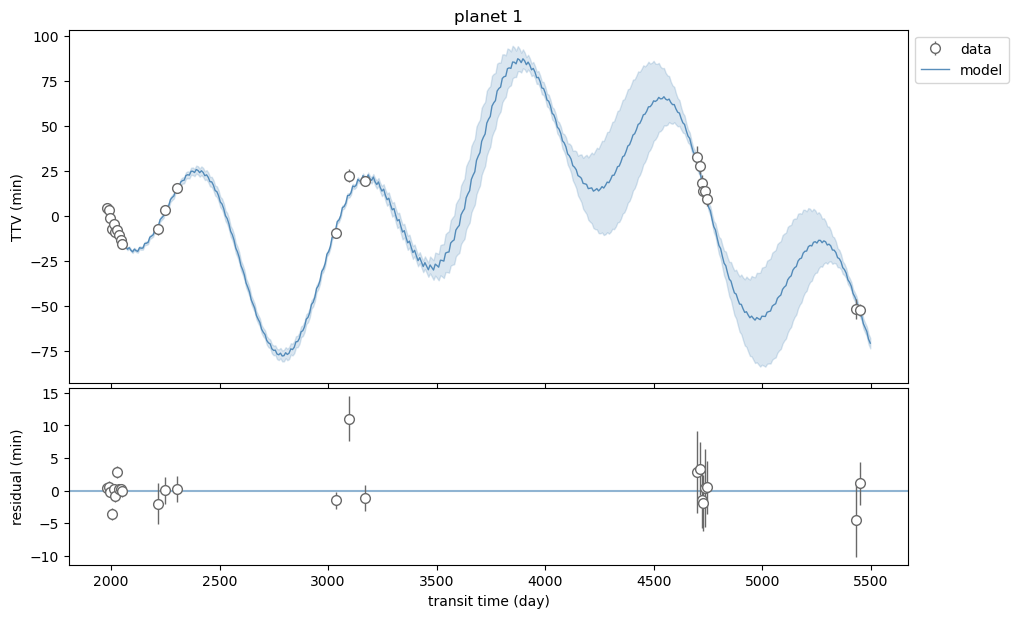

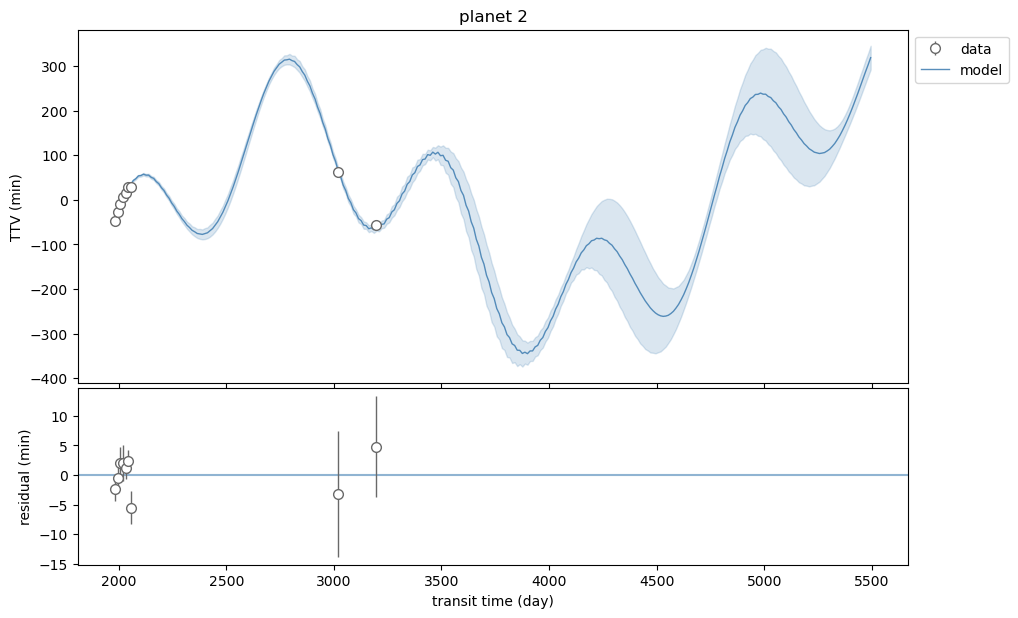

<Figure size 1920x1440 with 0 Axes>

In [73]:
jttv.plot_model(means, tcmodelunclist=stds)
plt.figure(dpi=300) 

## Project into future

In [74]:
### Read results
d = pd.read_csv("data/ttv_results.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err', 'Source', 'Instrument'])

### get times, errs from the data
list_of_obs_transit_times = []
list_of_transit_time_errs = []
# period_guess = [7.9222, 11.8993] # rough initial guess to track transit epochs (from Petigura 2020)
period_guess = [7.91975198, 11.90285385]
for j in range(2):
    list_of_obs_transit_times.append(np.array(d.Tc[d.Planet_num==j+1]))
    list_of_transit_time_errs.append(np.array(d.Tc_err[d.Planet_num==j+1]))
index_obs_b = np.array(d.Index[d.Planet_num==1])
index_obs_c = np.array(d.Index[d.Planet_num==2])

tcobs = []
errorobs = []
for j in range(2):
    tcobs.append(np.array(d.Tc[d.Planet_num == j + 1]))
    errorobs.append(np.array(d.Tc_err[d.Planet_num == j + 1]))

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_36604/780223280.py:2: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("data/ttv_results.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err', 'Source', 'Instrument'])


In [75]:
t_start = 1980.0
t_end_future = 8000.0
dt = 0.25
jttv_future = JaxTTV(t_start, t_end_future, dt, tcobs, period_guess, errorobs=errorobs)


# number of transiting planets:    2
# integration starts at:           1980.00
# first transit time in data:      1980.38
# last transit time in data:       5449.72
# integration ends at:             8000.00
# integration time step:           0.2500 (1/31 of innermost period)



In [76]:
posterior_transit_times_future = []

num_samples = samples['period'].shape[0]

for i in range(num_samples):
    if (i%500==0):
        print(f'{i}th draw')
    # extract the i-th draw
    sample_i = {k: v[i] for k, v in samples.items() if k not in ['tcmodel', 'ediff']}
    
    # get transit times for this draw
    tcall_i = jttv_future.get_transit_times_all_list(sample_i, truncate=False)
    posterior_transit_times_future.append(tcall_i)


0th draw
500th draw
1000th draw
1500th draw
2000th draw
2500th draw
3000th draw
3500th draw


In [22]:
#

In [77]:
# Convert list of dicts into list of arrays per planet
num_planets = len(tcobs)
posterior_transit_times_future_array = [
    np.array([draw[planet_idx] for draw in posterior_transit_times_future])
    for planet_idx in range(num_planets)
]

# Compute mean and std for each transit
means_future = [arr.mean(axis=0) for arr in posterior_transit_times_future_array]
stds_future  = [arr.std(axis=0)  for arr in posterior_transit_times_future_array]

In [78]:
print(posterior_transit_times_future_array)

[array([[1980.38401857, 1988.30405074, 1996.22213952, ..., 7976.50460319,
        7984.42790277, 7992.34982152],
       [1980.38405206, 1988.3041223 , 1996.2222866 , ..., 7976.47898931,
        7984.40234538, 7992.32465976],
       [1980.38306136, 1988.30342455, 1996.221534  , ..., 7976.54441431,
        7984.46668549, 7992.38704402],
       ...,
       [1980.3841401 , 1988.30415727, 1996.22255291, ..., 7976.45117864,
        7984.37407685, 7992.29658287],
       [1980.38410195, 1988.30408325, 1996.22249943, ..., 7976.46090071,
        7984.38379701, 7992.30621751],
       [1980.38416044, 1988.3041577 , 1996.2225169 , ..., 7976.46606045,
        7984.38917641, 7992.31172996]]), array([[1984.27276075, 1996.18443083, 2008.09159576, ..., 7969.18678102,
        7981.07667705, 7992.96953125],
       [1984.27374988, 1996.18474455, 2008.09156555, ..., 7969.28917611,
        7981.17855155, 7993.07012559],
       [1984.27286889, 1996.18454876, 2008.09155048, ..., 7969.04284044,
        7980.940

In [79]:
# np.savez("posterior_transit_times_outlier_removed.npz", *posterior_transit_times_future_array)
np.savez(
    "posterior_transit_times.npz",
    transit_times_b=posterior_transit_times_future_array[0],
    transit_times_c=posterior_transit_times_future_array[1]
)

In [80]:
data = np.load("posterior_transit_times.npz")
print(data)

arr0 = data['transit_times_b']
arr1 = data['transit_times_c']
print(arr0)
print(arr1)

NpzFile 'posterior_transit_times.npz' with keys: transit_times_b, transit_times_c
[[1980.38401857 1988.30405074 1996.22213952 ... 7976.50460319
  7984.42790277 7992.34982152]
 [1980.38405206 1988.3041223  1996.2222866  ... 7976.47898931
  7984.40234538 7992.32465976]
 [1980.38306136 1988.30342455 1996.221534   ... 7976.54441431
  7984.46668549 7992.38704402]
 ...
 [1980.3841401  1988.30415727 1996.22255291 ... 7976.45117864
  7984.37407685 7992.29658287]
 [1980.38410195 1988.30408325 1996.22249943 ... 7976.46090071
  7984.38379701 7992.30621751]
 [1980.38416044 1988.3041577  1996.2225169  ... 7976.46606045
  7984.38917641 7992.31172996]]
[[1984.27276075 1996.18443083 2008.09159576 ... 7969.18678102
  7981.07667705 7992.96953125]
 [1984.27374988 1996.18474455 2008.09156555 ... 7969.28917611
  7981.17855155 7993.07012559]
 [1984.27286889 1996.18454876 2008.09155048 ... 7969.04284044
  7980.94026132 7992.84028297]
 ...
 [1984.27441745 1996.18386546 2008.09185145 ... 7969.36517781
  7981.2

In [48]:
with open("posterior_transit_times_outlier_removed.csv", "w") as f:
    print(posterior_transit_times_future_array, file=f)
# combined = np.vstack(posterior_transit_times_future_array)
# np.savetxt("posterior_transit_times_outlier_removed.csv", combined, delimiter=",")


/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


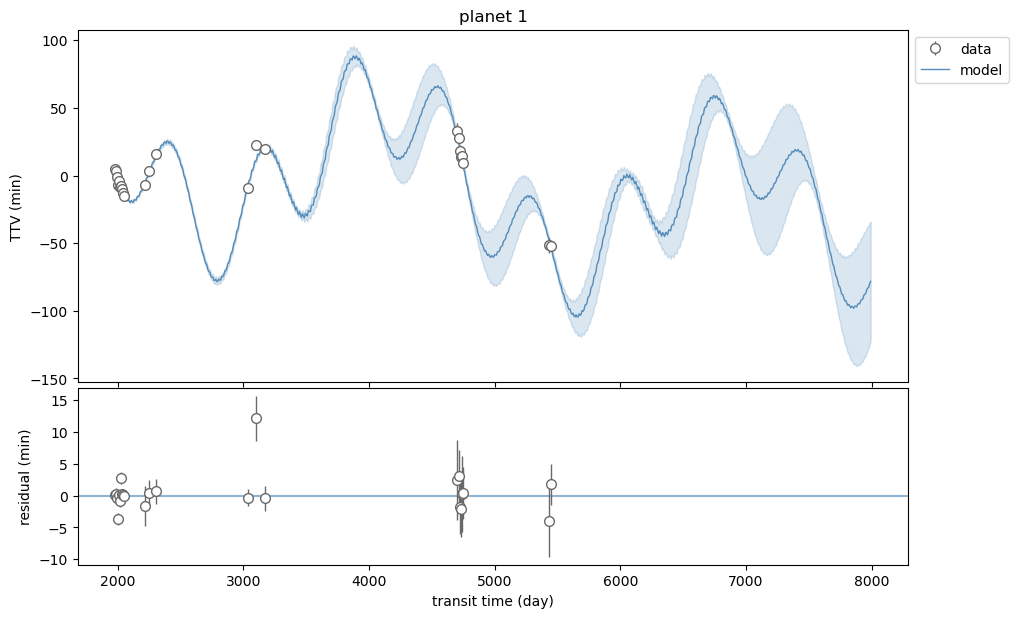

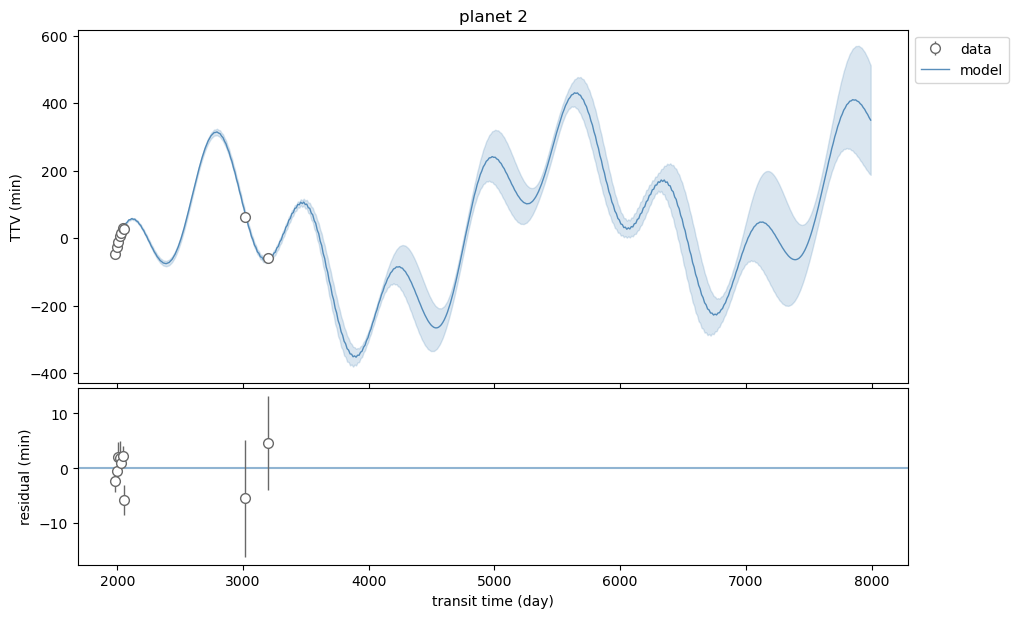

In [45]:
jttv_future.plot_model(means_future, tcmodelunclist=stds_future)
# plt.title("Extrapolated Transit Times to 8000 days")
plt.show()

In [20]:
# Convert all arrays to regular lists
fit_data = {
    "jnkep_mcmc_times_ext": {
        "b": means_future[0].tolist(),
        "c": means_future[1].tolist()
    },
    "jnkep_mcmc_times_ext_err": {
        "b": stds_future[0].tolist(),
        "c": stds_future[1].tolist()
    }
}

# Save to JSON
with open("data/jnkep_mcmc_data_extrapolate.json", "w") as f:
    json.dump(fit_data, f, indent=4)

print("Data saved successfully.")

Data saved successfully.


In [21]:
indices_b = np.arange(0, len(means_future[0]), 1)
indices_c = np.arange(0, len(means_future[1]), 1)

planet_id = []
for i in range(len(means_future[0])):
    planet_id.append('b')
for i in range(len(means_future[1])):
    planet_id.append('c')

transit_pred = []
for i in range(len(means_future[0])):
    transit_pred.append(means_future[0][i])
for i in range(len(means_future[1])):
    transit_pred.append(means_future[1][i])

transit_pred_err = []
for i in range(len(means_future[0])):
    transit_pred_err.append(stds_future[0][i])
for i in range(len(means_future[1])):
    transit_pred_err.append(stds_future[1][i])

transit_index = []
for i in range(len(means_future[0])):
    transit_index.append(indices_b[i])
for i in range(len(means_future[1])):
    transit_index.append(indices_c[i])

### convert times to UTC
from astropy.time import Time

# Convert each BJD_TDB to UTC (keep as Time objects)
transit_bjd = [t + petigura_offset for t in transit_pred]
utc_times = [Time(bjd, format='jd', scale='tdb').utc for bjd in transit_bjd]

# Format as 'YYYY Mon DD'
formatted_times = [t.datetime.strftime('%Y %b %d') for t in utc_times]

# print(formatted_times)


/opt/homebrew/anaconda3/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [22]:
# Get the sort indices for transit_pred
sort_idx = np.argsort(transit_pred)

# Apply the sort indices to all lists
transit_pred_sorted = [transit_pred[i] for i in sort_idx]
transit_pred_err_sorted = [transit_pred_err[i] for i in sort_idx]
planet_id_sorted = [planet_id[i] for i in sort_idx]
transit_index_sorted = [transit_index[i] for i in sort_idx]
formatted_times_sorted = [formatted_times[i] for i in sort_idx]



In [23]:
# Create a DataFrame from the sorted lists
df = pd.DataFrame({
    'planet_id': planet_id_sorted,
    'transit_index': transit_index_sorted,
    'transit_time_utc': formatted_times_sorted,
    'transit_pred': transit_pred_sorted,
    'transit_pred_err': transit_pred_err_sorted,
})

# Save to CSV
df.to_csv('data/transit_predictions.csv', index=False)

print("CSV saved as 'transit_predictions.csv'")

CSV saved as 'transit_predictions.csv'


In [24]:
# Output file name
output_file = "data/toi_1339_transit_predictions_table.txt"
    
with open(output_file, "w") as f:
    f.write("% planet, transit index, utc time, time, time_error\n")
    for p, idx, t_utc, t, terr in zip(planet_id_sorted, transit_index_sorted, formatted_times_sorted, transit_pred_sorted, transit_pred_err_sorted):
        # planet = p
        # instrument = "TESS"
        # notes = "A"   # you can change this if needed
        f.write(f"{p} & {idx} & {t_utc} & {t:.4f} & {terr:.4f} \\\\\n")
    
print(f"Formatted results saved to {output_file}")

Formatted results saved to data/toi_1339_transit_predictions_table.txt


## Trace and corner plots 

In [14]:
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [15]:
import arviz as az
# idata = az.from_numpyro(mcmc)
samples_sorted = mcmc.get_samples(group_by_chain=True)
idata = az.from_dict(posterior=samples_sorted)


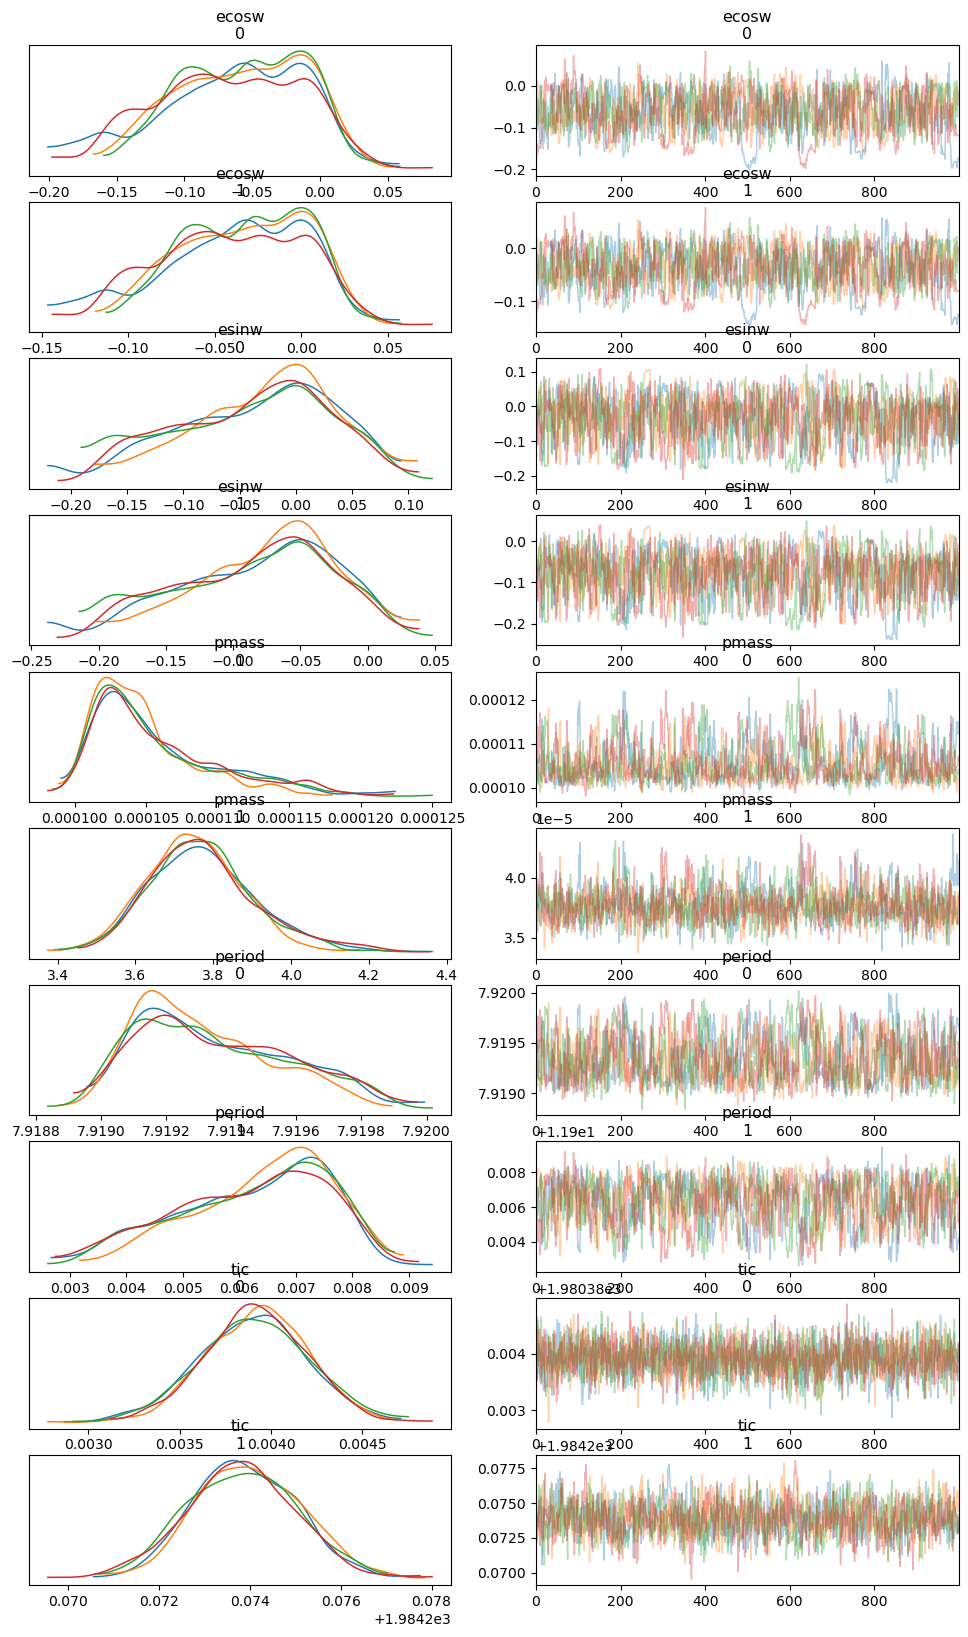

<Figure size 1920x1440 with 0 Axes>

In [16]:
fig = az.plot_trace(idata, var_names=sample_keys, compact=False)
plt.figure(dpi=300) 
plt.tight_layout(pad=0.2)

In [17]:
# import arviz as az
# idata = az.from_numpyro(mcmc)
# fig = az.plot_trace(idata, var_names=sample_keys, compact=False)
# plt.figure(dpi=300) 
# plt.tight_layout(pad=0.2)

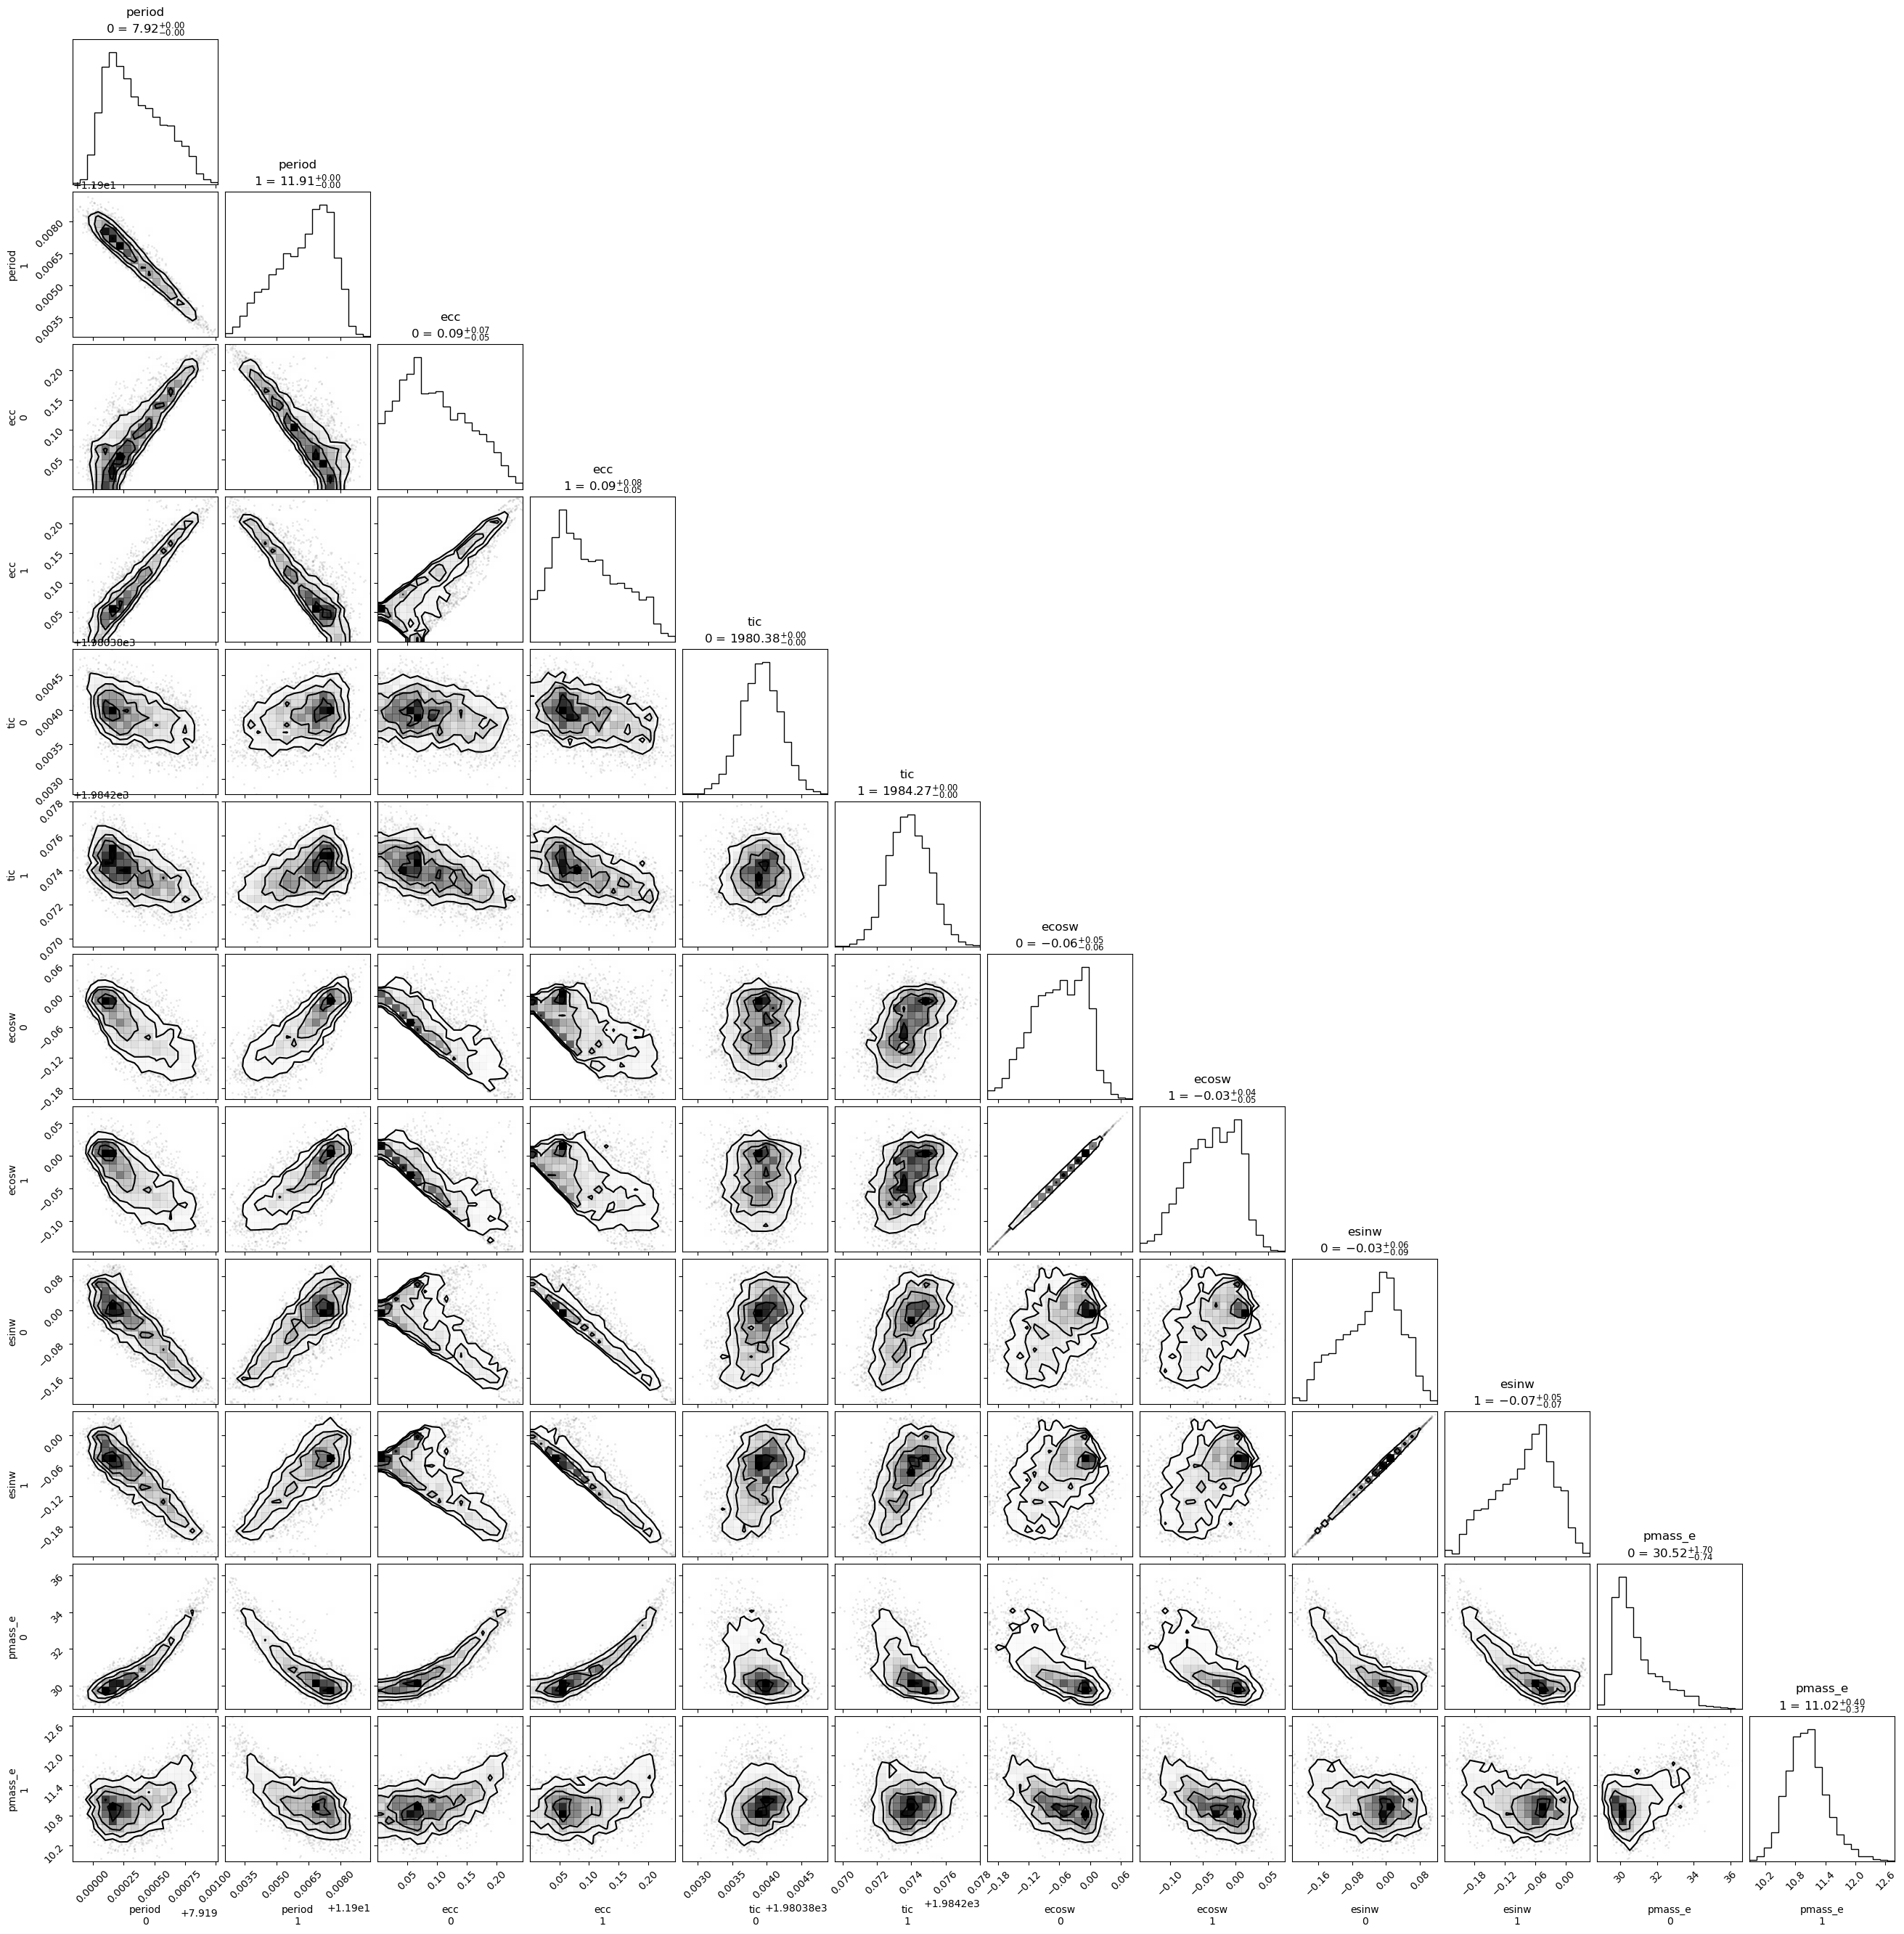

In [21]:
# idata.posterior['mu'] = idata.posterior['pmass'] / 3.003e-6
import astropy.constants as u
convert = ((0.88*u.M_sun) / u.M_earth).value
idata.posterior['pmass_e'] = idata.posterior['pmass'] * convert
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata, var_names=names, show_titles=True)

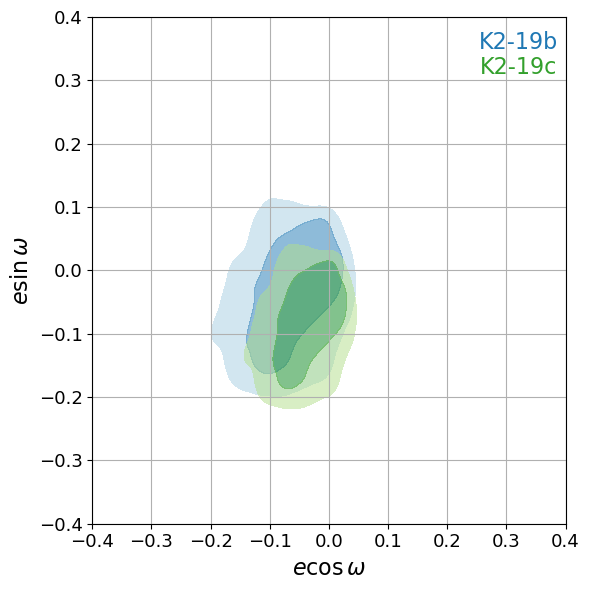

In [19]:
### 2D posterior for ecosw and esinw 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_b, esinw_b)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.32, 0.35, 'K2-19b', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.32, 0.31, 'K2-19c', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])

# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
az.summary(idata, var_names=["ecc","ecosw_scaled","esinw_scaled","ecosw","esinw", "pmass_scaled","period_scaled","tic_scaled"], round_to=3)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ecc[0],0.096,0.057,0.003,0.195,0.003,0.002,372.520,428.704,1.012
ecc[1],0.098,0.056,0.009,0.204,0.003,0.001,375.037,448.350,1.010
ecosw_scaled[0],0.376,0.101,0.182,0.535,0.005,0.004,356.768,202.978,1.010
ecosw_scaled[1],0.427,0.079,0.274,0.548,0.004,0.003,357.356,202.978,1.010
esinw_scaled[0],0.429,0.137,0.164,0.648,0.007,0.004,434.115,382.975,1.006
esinw_scaled[1],0.337,0.114,0.115,0.518,0.005,0.003,434.264,379.487,1.006
ecosw[0],-0.062,0.051,-0.159,0.017,0.003,0.002,356.768,202.978,1.010
ecosw[1],-0.037,0.039,-0.113,0.024,0.002,0.001,357.356,202.978,1.010
esinw[0],-0.036,0.069,-0.168,0.074,0.003,0.002,434.115,382.975,1.006
esinw[1],-0.081,0.057,-0.192,0.009,0.003,0.002,434.264,379.487,1.006


# Extracting values from posteriors

In [58]:
### posterior samples 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]
Per_b = samples["period"][:,0] # [days]
Tc_b = samples["tic"][:,0] # [days]
pmass_b = samples["pmass"][:, 0] # [solar mass]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]
Per_c = samples["period"][:,1] # [days]
Tc_c = samples["tic"][:,1] # [days]
pmass_c = samples["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = ((0.88*u.M_sun) / u.M_earth).value
pmass_earth_b = pmass_b * convert
pmass_earth_c = pmass_c * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_b = np.sqrt(ecosw_b**2 + esinw_b**2)
omega_rad_b = np.arctan2(esinw_b, ecosw_b)
omega_deg_b = np.rad2deg(omega_rad_b)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)


### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = [np.radians(value_Omega_b)] * len(omega_rad_b)  # [rad]
value_Omega_c = 0 # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]

pomega_rad_b = omega_rad_b + Omega_b
pomega_rad_c = omega_rad_c + Omega_c

# Delta_omega_rad = np.arctan2(np.sin(omega_rad_c - omega_rad_b), np.cos(omega_rad_c - omega_rad_b))
Delta_omega_rad = (omega_rad_c - omega_rad_b + np.pi) % (2*np.pi) - np.pi
# Delta_omega_rad = omega_rad_c - omega_rad_b
Delta_omega_deg = np.rad2deg(Delta_omega_rad)

In [70]:
### save posterior draws 
# stack the parameters column-wise: shape (nsamples, ncols)
rows = np.column_stack([
    Per_b,
    Tc_b,
    ecosw_b,
    esinw_b,
    pmass_earth_b,
    Per_c,
    Tc_c,
    ecosw_c,
    esinw_c,
    pmass_earth_c
])

# write to text file in LaTeX table row format
with open("posterior_table.tex", "w") as f:
    for row in rows:
        # format each number (here 6 decimals, adjust as needed)
        line = " & ".join([f"{val:.4f}" for val in row]) + r" \\"
        f.write(line + "\n")

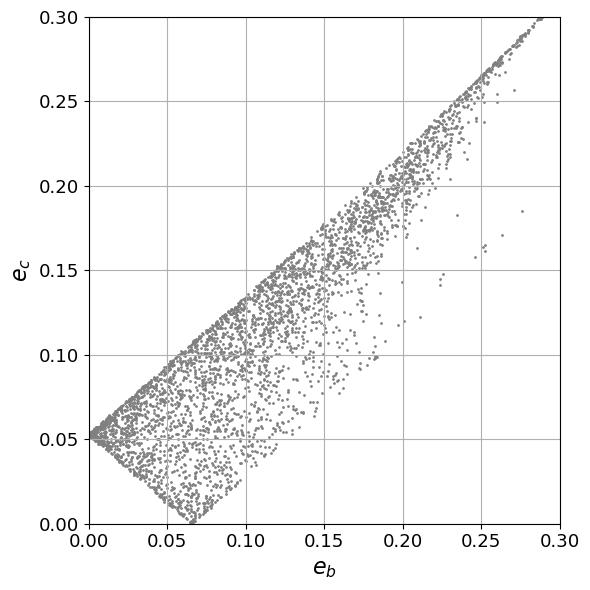

In [59]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(ecc_b, ecc_c, s=1, c="grey")
plt.xlabel(r"$e_b$", fontsize=16)
plt.ylabel(r"$e_c$", fontsize=16)

plt.tick_params(axis='both', labelsize=13) 
plt.xlim(0.0,0.30)
plt.ylim(0.0,0.30)
plt.xlim
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()

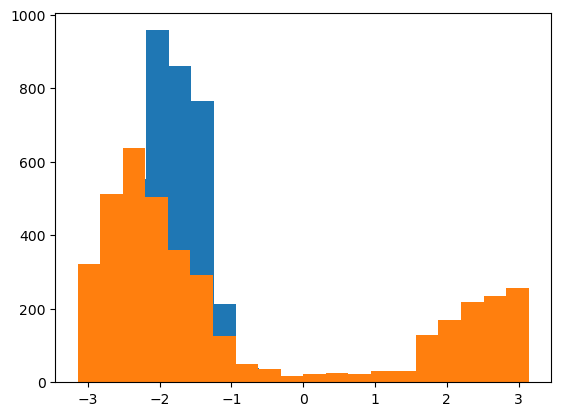

In [60]:
plt.hist(omega_rad_c, bins=20)
plt.hist(omega_rad_b, bins=20)
plt.show()

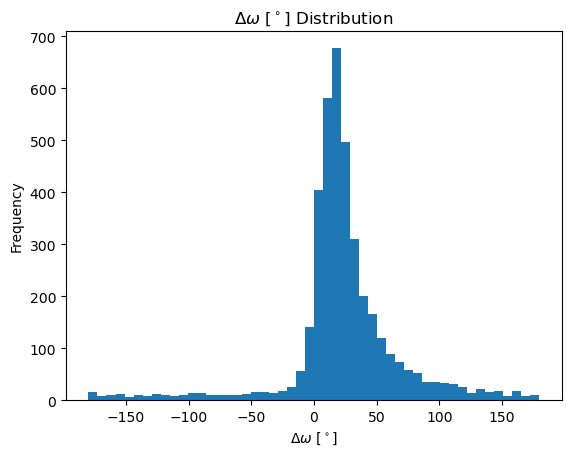

In [61]:
plt.hist(Delta_omega_deg, bins=50)
plt.title(r"$\Delta\omega\ [^\circ]$ Distribution")
plt.xlabel(r"$\Delta\omega\ [^\circ]$")
plt.ylabel("Frequency")
plt.show()

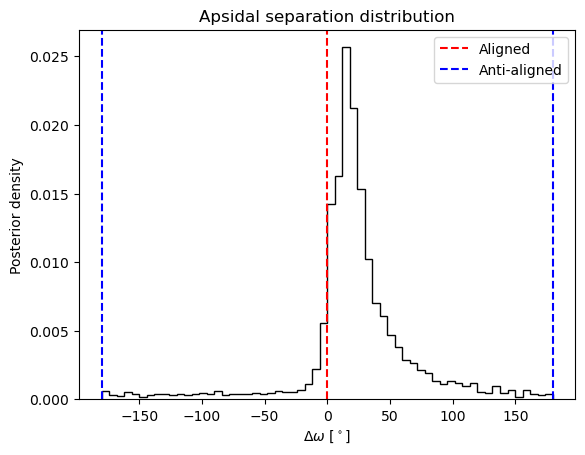

In [62]:
plt.hist(Delta_omega_deg, bins=60, density=True, histtype="step", color="k")
plt.xlabel(r"$\Delta\omega\ [^\circ]$")
plt.ylabel("Posterior density")
plt.title("Apsidal separation distribution")
plt.axvline(0, color="r", ls="--", label="Aligned")
plt.axvline(180, color="b", ls="--", label="Anti-aligned")
plt.axvline(-180, color="b", ls="--")
plt.legend()
plt.show()

In [63]:
# samples_array = np.vstack([
#     ecc_b, 
#     omega_deg_b, 
#     Per_b, 
#     Tc_b, 
#     pmass_earth_b,
#     ecc_c, 
#     omega_deg_c, 
#     Per_c, 
#     Tc_c, 
#     pmass_earth_c,
#     Delta_omega_deg
# ]).T

# # Labels for the axes
# labels = [
#     r"$e_b$", r"$\omega_b\ [^\circ]$", r"$P_b\ [\mathrm{days}]$", r"$T_{c,b}\ [\mathrm{days}]$", r"$M_b\ [M_\oplus]$",
#     r"$e_c$", r"$\omega_c\ [^\circ]$", r"$P_c\ [\mathrm{days}]$", r"$T_{c,c}\ [\mathrm{days}]$", r"$M_c\ [M_\oplus]$",
#     r"$\Delta\omega\ [^\circ]$"
# ]

# # Make the corner plot
# figure = corner.corner(
#     samples_array,
#     labels=labels,
#     show_titles=True,
#     title_fmt=".2f",
#     quantiles=[0.16, 0.5, 0.84],
#     label_kwargs={"fontsize": 12}
# )

# plt.show()

In [64]:
# # Stack all parameters into one array (shape: n_samples × n_dim)
# samples_array = np.vstack([
#     ecosw_b, esinw_b,
#     ecc_b, omega_deg_b,
#     Per_b, Tc_b, pmass_earth_b,
#     ecosw_c, esinw_c,
#     ecc_c, omega_deg_c,
#     Per_c, Tc_c, pmass_earth_c,
#     Delta_omega_deg
# ]).T

# # Axis labels
# labels = [
#     r"$e\cos\omega_b$", r"$e\sin\omega_b$",
#     r"$e_b$", r"$\omega_b\ [^\circ]$",
#     r"$P_b\ [\mathrm{days}]$", r"$T_{c,b}\ [\mathrm{days}]$", r"$M_b\ [M_\oplus]$",
#     r"$e\cos\omega_c$", r"$e\sin\omega_c$",
#     r"$e_c$", r"$\omega_c\ [^\circ]$",
#     r"$P_c\ [\mathrm{days}]$", r"$T_{c,c}\ [\mathrm{days}]$", r"$M_c\ [M_\oplus]$",
#     r"$\Delta\omega\ [^\circ]$"
# ]

# # Make the corner plot
# figure = corner.corner(
#     samples_array,
#     labels=labels,
#     show_titles=True,
#     title_fmt=".2f",
#     quantiles=[0.16, 0.5, 0.84],
#     label_kwargs={"fontsize": 12}
# )
# # Add grid lines to all panels
# for ax in figure.get_axes():
#     ax.grid(True, alpha=0.5)  # you can adjust alpha, linestyle, etc.

# plt.show()


In [65]:
# # Stack geometry parameters only
# geom_samples = np.vstack([
#     ecosw_b, esinw_b,
#     ecc_b, omega_deg_b,
#     ecosw_c, esinw_c,
#     ecc_c, omega_deg_c,
#     Delta_omega_deg
# ]).T

# # Labels for axes
# geom_labels = [
#     r"$e\cos\omega_b$", r"$e\sin\omega_b$",
#     r"$e_b$", r"$\omega_b\ [^\circ]$",
#     r"$e\cos\omega_c$", r"$e\sin\omega_c$",
#     r"$e_c$", r"$\omega_c\ [^\circ]$",
#     r"$\Delta\omega\ [^\circ]$"
# ]

# # Make the corner plot
# fig = corner.corner(
#     geom_samples,
#     labels=geom_labels,
#     show_titles=True,
#     title_fmt=".2f",
#     quantiles=[0.16, 0.5, 0.84],
#     label_kwargs={"fontsize": 12}
# )
# # Add grid lines to all panels
# for ax in fig.get_axes():
#     ax.grid(True, alpha=0.5)  # you can adjust alpha, linestyle, etc.

# plt.show()

# envelope mass fraction

In [38]:
lopez = False

In [39]:

if lopez: 
    df_100myr = pd.read_csv(
        '/Users/pentrican10/Projects/tess-resonant-systems/data/model_table_100myr.txt',
        sep=r'\s+',         # regex for 1+ spaces
        skiprows=3,         # adjust to skip header/title lines
        engine='python'     # sometimes needed for regex separator
    )
    
    df_1gyr = pd.read_csv(
        '/Users/pentrican10/Projects/tess-resonant-systems/data/model_table_1gyr.txt',
        sep=r'\s+',         # regex for 1+ spaces
        skiprows=3,         # adjust to skip header/title lines
        engine='python'     # sometimes needed for regex separator
    )
    
    df_10gyr = pd.read_csv(
        '/Users/pentrican10/Projects/tess-resonant-systems/data/model_table_10gyr.txt',
        sep=r'\s+',         # regex for 1+ spaces
        skiprows=3,         # adjust to skip header/title lines
        engine='python'     # sometimes needed for regex separator
    )
    # print(df_10gyr)
    
    ages = np.array([0.1, 1.0, 10.0]) # in Gyr

else:
    df_10myr = pd.read_csv("/Users/pentrican10/Projects/tess-resonant-systems/data/20mbar_10Myr_1x.csv", comment='#')
    df_100myr = pd.read_csv("/Users/pentrican10/Projects/tess-resonant-systems/data/20mbar_100Myr_1x.csv", comment='#')
    df_1gyr = pd.read_csv("/Users/pentrican10/Projects/tess-resonant-systems/data/20mbar_1Gyr_1x.csv", comment='#')
    df_10gyr = pd.read_csv("/Users/pentrican10/Projects/tess-resonant-systems/data/20mbar_10Gyr_1x.csv", comment='#')
    
    ages = np.array([0.01, 0.1, 1, 10]) # in Gyr

In [40]:
fenv_cols = df_10gyr.columns[2:]
print(fenv_cols)

# envelope fractions as decimals 
f_envs = np.array([float(c.replace('%', ''))/100 for c in fenv_cols])

Index(['0.10%', '0.20%', '0.50%', '1%', '2%', '5%', '10%', '20%'], dtype='object')


In [41]:
### mass and flux values same for three models 
if lopez:
    flux_array = df_10gyr['Flux(F_oplus)'].values
    mass_array = df_10gyr['Mass(M_oplus)'].values
else: 
    flux_array = df_10gyr['flux (F_e)'].values
    mass_array = df_10gyr['core mass (M_e)'].values
fluxes = np.sort(np.unique(flux_array))
masses = np.sort(np.unique(mass_array))


In [42]:
radii_table = np.zeros((len(ages), len(fluxes),len(masses), len(f_envs)))
if lopez:
    dataframes = [df_100myr, df_1gyr, df_10gyr]
else: 
    dataframes = [df_10myr, df_100myr, df_1gyr, df_10gyr]
for k, df in enumerate(dataframes):
    for i, F in enumerate(fluxes):
        for j, M in enumerate(masses):
            idx = np.where((flux_array == F) & (mass_array == M))[0][0]
            radii_table[k, i, j, :] = df.loc[idx, fenv_cols].values


In [43]:
from scipy.interpolate import interp1d, RegularGridInterpolator

def sample_asymmetric_normal(median, lo, hi, nsamp=10000):
    """
    Sample from a split-normal (two-piece normal) distribution defined
    by median, lower bound (lo), and upper bound (hi).
    Here lo and hi are the 1-sigma distances: median - lo_val, hi_val - median.
    If lo==hi (or one is None), falls back to symmetric normal.
    
    Parameters
    ----------
    median : float
        central value
    lo : float
        lower 1-sigma bound (value < median) OR absolute sigma_left (positive)
        If given as the upper bound value, the function expects the caller to pass
        the lower sigma = median - lo_value. (See usage below.)
    hi : float
        upper 1-sigma bound (value > median) OR absolute sigma_right (positive)
    nsamp : int
        number of samples
    Returns
    -------
    samples : ndarray (nsamp,)
    """
    # Interpret arguments: if lo < median and hi > median assume they are values, convert
    # to sigmas: sigma_left = median - lo, sigma_right = hi - median
    sigma_left = None
    sigma_right = None
    if (lo is not None) and (hi is not None) and (lo < median < hi):
        sigma_left = median - lo
        sigma_right = hi - median
    else:
        # assume lo and hi are sigmas already (positive)
        if lo is None and hi is None:
            raise ValueError("Provide either (lo_value, hi_value) or (sigma_left, sigma_right).")
        sigma_left = float(lo) if lo is not None else float(hi)
        sigma_right = float(hi) if hi is not None else float(lo)

    # if sigmas are (nearly) equal, do symmetric normal
    if np.isclose(sigma_left, sigma_right):
        return np.random.normal(loc=median, scale=sigma_left, size=nsamp)

    # split-normal: draw standard normal z; scale negative z by sigma_left, positive by sigma_right
    z = np.random.normal(size=nsamp)
    z_scaled = np.where(z < 0, z * sigma_left, z * sigma_right)
    return median + z_scaled

def sample_symmetric_normal(val, sigma, nsamp=10000):
    return np.random.normal(loc=val, scale=sigma, size=nsamp)


# -----------------------
# Kepler -> semi-major axis (AU)
# -----------------------
import astropy.constants as const
import astropy.units as u
def semi_major_axis_from_period(P_days, Mstar_Msun):
    P = (P_days * u.day).to(u.s)
    Mstar = (Mstar_Msun * const.M_sun).to(u.kg)
    a = ( (const.G * Mstar * P**2) / (4 * np.pi**2) )**(1/3)
    return a.to(u.AU).value

def incident_flux_Fearth(Lstar_over_Lsun, a_AU):
    return (Lstar_over_Lsun) * (a_AU**-2)

# -----------------------
# your Lopez inversion function (expects Earth units)
# (use the version you already validated)
# -----------------------
def f_env_from_lopez(Rp, Mp, Fp, age_Gyr):
    coef = 2.06
    a_mp = -0.21
    a_fenv = 0.59
    a_fp = 0.044
    a_age = -0.18

    R_core = Mp**0.25
    R_env = Rp - R_core
    if R_env <= 0:
        return 0.0

    factor = (R_env / coef) * (Mp ** (+0.21)) * (Fp ** (-0.044)) * ((age_Gyr/5.0) ** (+0.18))
    if factor <= 0 or not np.isfinite(factor):
        return 0.0
    f_env = 0.05 * (factor ** (1.0 / a_fenv))
    return float(np.clip(f_env, 0.0, 1.0))

# -----------------------
# Monte Carlo wrapper handling asymmetric/symmetric errors
# -----------------------
def fenv_mc_with_errors(
    Rp, Rp_err_sym,  # radius and symmetric 1-sigma error (R_earth)
    Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma,  # for asymmetric: pass lo_value, hi_value; for symmetric pass sigma twice
    P_median, P_lo_or_sigma, P_hi_or_sigma,     # period (days) same pattern
    Mstar_Msun, Lstar_over_Lsun, age_Gyr,
    nsamp=20000
):
    """
    Return median, 16th, 84th percentiles of f_env and intermediate diagnostics.
    Mp_{lo,hi} and P_{lo,hi} may be provided either as absolute bounds (values) or as sigmas.
    For convenience, if you have symmetric error just pass sigma for lo and hi.
    """
    # Radius: symmetric normal
    Rp_samps = sample_symmetric_normal(Rp, Rp_err_sym, nsamp=nsamp)

    # Mass: determine if the user passed bounds or sigmas
    # If they passed lo < median < hi treat lo/hi as bound-values (common usage)
    if (Mp_lo_or_sigma is not None) and (Mp_hi_or_sigma is not None) and (Mp_lo_or_sigma < Mp_median < Mp_hi_or_sigma):
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp=nsamp)
    else:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp=nsamp)

    # Period:
    if (P_lo_or_sigma is not None) and (P_hi_or_sigma is not None) and (P_lo_or_sigma < P_median < P_hi_or_sigma):
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp=nsamp)
    else:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp=nsamp)

    fenv_samps = []
    Fp_samps = []
    a_samps = []

    for Rp_i, Mp_i, P_i in zip(Rp_samps, Mp_samps, P_samps):
        # skip unphysical draws
        if Rp_i <= 0 or Mp_i <= 0 or P_i <= 0:
            continue
        a_i = semi_major_axis_from_period(P_i, Mstar_Msun)
        Fp_i = incident_flux_Fearth(Lstar_over_Lsun, a_i)
        fenv_samps.append(f_env_from_lopez(Rp_i, Mp_i, Fp_i, age_Gyr))
        Fp_samps.append(Fp_i)
        a_samps.append(a_i)

    fenv_samps = np.array(fenv_samps)
    Fp_samps = np.array(Fp_samps)
    a_samps = np.array(a_samps)

    out = {
        "fenv_median": np.median(fenv_samps),
        "fenv_lo": np.percentile(fenv_samps, 16),
        "fenv_hi": np.percentile(fenv_samps, 84),
        "Fp_med": np.median(Fp_samps),
        "Fp_16": np.percentile(Fp_samps, 16),
        "Fp_84": np.percentile(Fp_samps, 84),
        "a_med_AU": np.median(a_samps),
    }
    return out


def f_env_from_table(Rp_obs, Mp_obs, F_obs, age, fluxes, masses, f_envs, interp_func):
    """
    Estimate envelope mass fraction by inverting Lopez & Fortney grids.
    """
    # Radius as function of f_env at this (age, F, M)
    Rp_curve = [interp_func([[age, F_obs, Mp_obs, f]])[0] for f in f_envs]
    
    # # Outside grid?
    # if Rp_obs < min(Rp_curve) or Rp_obs > max(Rp_curve):
    #     return np.nan
    
    # Invert Rp -> f_env
    f_interp = interp1d(Rp_curve, f_envs, kind="linear", fill_value="extrapolate")
    return float(f_interp(Rp_obs))


# ----- Monte Carlo wrapper -----
# compute the envelope fractions with observational uncertainties 
def fenv_mc_table(
    Rp, Rp_err_sym,
    Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma,
    P_median, P_lo_or_sigma, P_hi_or_sigma,
    M_star, M_star_err, L_star, L_star_err, age, age_err,
    fluxes, masses, f_envs, radii_table,
    interp_func, nsamp=15000
):
    # Sample radius, m_star, and L_star, symmetric Gaussian
    Rp_samps = sample_symmetric_normal(Rp, Rp_err_sym, nsamp)
    M_star_samps = sample_symmetric_normal(M_star, M_star_err, nsamp)
    L_star_samps = sample_symmetric_normal(L_star, L_star_err, nsamp)
    age_samps = sample_symmetric_normal(age, age_err, nsamp)
    
    # Sample mass, allow asymmetric errors
    if Mp_lo_or_sigma < Mp_median < Mp_hi_or_sigma:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp)
    else:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp)
    
    # Sample period, allow asymmetric errors
    if P_lo_or_sigma < P_median < P_hi_or_sigma:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp)
    else:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp)
    
    fenv_samps = []
    Fp_samps = []
    a_samps = []

    # loop over samples 
    for Rp_i, Mp_i, P_i, Mstar_i, Lstar_i, age_i in zip(Rp_samps, Mp_samps, P_samps, M_star_samps, L_star_samps, age_samps):
        if Rp_i <= 0 or Mp_i <= 0 or P_i <= 0 or Mstar_i <=0 or Lstar_i <= 0: # skip unphysical samples 
            continue
        # compute semi-major axis and incident flux at planet
        a_i = semi_major_axis_from_period(P_i, Mstar_i)
        Fp_i = incident_flux_Fearth(Lstar_i, a_i)
        # calculate envelope fraction by interpolating table
        f_env_i = f_env_from_table(Rp_i, Mp_i, Fp_i, age_i, fluxes, masses, f_envs, interp_func)
        # f_env_i = f_env_from_table(Rp_i, Mp_i, Fp_i, age_i, fluxes, masses, f_envs, radii_table)
        # store results 
        fenv_samps.append(f_env_i)
        Fp_samps.append(Fp_i)
        a_samps.append(a_i)
    
    fenv_samps = np.array(fenv_samps)
    Fp_samps = np.array(Fp_samps)
    a_samps = np.array(a_samps)

    # compute and save median and 1-sigma bounds for envelope fraction and flux
    out = {
        "fenv_median": np.median(fenv_samps),
        "fenv_lo": np.percentile(fenv_samps, 16),
        "fenv_hi": np.percentile(fenv_samps, 84),
        "Fp_med": np.median(Fp_samps),
        "Fp_16": np.percentile(Fp_samps, 16),
        "Fp_84": np.percentile(Fp_samps, 84),
        "a_med_AU": np.median(a_samps)
    }
    return out



from scipy.interpolate import griddata

def fill_missing_radii(ages, fluxes, masses, f_envs, radii_raw):
    """
    Fill missing values in the Lopez & Fortney radius grids.
    radii_raw is a 4D array with NaNs.
    """
    radii_filled = radii_raw.copy()
    log_fluxes = np.log10(fluxes)

    for ia, age in enumerate(ages):
        for i_f, f_env in enumerate(f_envs):
            # Collect known points
            known = []
            values = []
            for iF, F in enumerate(fluxes):
                for iM, M in enumerate(masses):
                    val = radii_raw[ia, iF, iM, i_f]
                    if np.isfinite(val):
                        known.append((log_fluxes[iF], M))
                        values.append(val)

            known = np.array(known)
            values = np.array(values)

            # Grid of all (logF, M)
            grid_F, grid_M = np.meshgrid(log_fluxes, masses, indexing="ij")
            pts = np.column_stack([grid_F.ravel(), grid_M.ravel()])

            # Interpolate
            filled_vals = griddata(known, values, pts, method="linear")

            # Fallback for remaining NaNs: nearest neighbor
            nan_mask = np.isnan(filled_vals)
            if np.any(nan_mask):
                filled_vals[nan_mask] = griddata(
                    known, values, pts[nan_mask], method="nearest"
                )

            # Assign back
            radii_filled[ia, :, :, i_f] = filled_vals.reshape(len(fluxes), len(masses))

    return radii_filled

In [44]:
def get_median_and_1sigma(samples):
    median = np.median(samples)
    lower = np.percentile(samples, 16)
    upper = np.percentile(samples, 84)
    return median, median - lower, upper - median


In [45]:
m_star = 0.88 # Msun 
m_star_err = 0.03
L_star = 10**(-0.2919551) # L/Lsun 
L_star_err = 10**(0.019)
age = 2.0
age_err = 1.0

print('calculating interp function')
radii_table_filled = fill_missing_radii(ages, fluxes, masses, f_envs, radii_table)
interp_func = RegularGridInterpolator(
    (ages, fluxes, masses, f_envs),
    radii_table_filled,
    bounds_error=False,
    fill_value=None
)

rade_b_val = 7.0
rade_b_err = 0.2
Per_b_med, Per_b_lo, Per_b_hi = get_median_and_1sigma(Per_b)
pmass_earth_b_median, pmass_earth_b_lo, pmass_earth_b_hi = get_median_and_1sigma(pmass_earth_b)

# run MC for b
print('calculating fenv b')
res_b = fenv_mc_table(
    Rp=rade_b_val, Rp_err_sym=rade_b_err,
    Mp_median=pmass_earth_b_median, Mp_lo_or_sigma=pmass_earth_b_lo, Mp_hi_or_sigma=pmass_earth_b_hi,
    P_median=Per_b_med, P_lo_or_sigma=Per_b_lo, P_hi_or_sigma=Per_b_hi,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)



rade_c_val = 4.1
rade_c_err = 0.2
Per_c_med, Per_c_lo, Per_c_hi = get_median_and_1sigma(Per_c)
pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi = get_median_and_1sigma(pmass_earth_c)

# run MC for c
print('calculating fenv c')
res_c = fenv_mc_table(
    Rp=rade_c_val, Rp_err_sym=rade_c_err,
    Mp_median=pmass_earth_c_median, Mp_lo_or_sigma=pmass_earth_c_lo, Mp_hi_or_sigma=pmass_earth_c_hi,
    P_median=Per_c_med, P_lo_or_sigma=Per_c_lo, P_hi_or_sigma=Per_c_hi,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)


# assemble table
table = pd.DataFrame([
    {"planet":"b", "fenv_med":res_b["fenv_median"], "fenv_lo":res_b["fenv_lo"], "fenv_hi":res_b["fenv_hi"],
     "Fp_med":res_b["Fp_med"], "a_AU":res_b["a_med_AU"]},
    {"planet":"c", "fenv_med":res_c["fenv_median"], "fenv_lo":res_c["fenv_lo"], "fenv_hi":res_c["fenv_hi"],
     "Fp_med":res_c["Fp_med"], "a_AU":res_c["a_med_AU"]},
])

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print(table)

calculating interp function
calculating fenv b
calculating fenv c
  planet  fenv_med  fenv_lo  fenv_hi  Fp_med  a_AU
0      b     0.306    0.226    0.385 168.825 0.075
1      c     0.075    0.058    0.091  97.872 0.098


In [46]:
fenv_b_med = res_b["fenv_median"] * 100
fenv_b_err_hi = (res_b["fenv_hi"]-res_b["fenv_median"]) *100
fenv_b_err_lo = (res_b["fenv_median"] - res_b["fenv_lo"]) *100

fenv_c_med = res_c["fenv_median"]*100
fenv_c_err_hi = (res_c["fenv_hi"]-res_c["fenv_median"]) *100
fenv_c_err_lo = (res_c["fenv_median"] - res_c["fenv_lo"])*100


In [47]:
print(f"fenv_b = {fenv_b_med:.3f}% (+{fenv_b_err_hi:.3f}/-{fenv_b_err_lo:.3f})%")
print(f"fenv_c = {fenv_c_med:.3f}% (+{fenv_c_err_hi:.3f}/-{fenv_c_err_lo:.3f})%")


fenv_b = 30.627% (+7.888/-8.064)%
fenv_c = 7.459% (+1.637/-1.679)%


# save values

In [48]:
def get_median_and_1sigma(samples):
    median = np.median(samples)
    lower = np.percentile(samples, 16)
    upper = np.percentile(samples, 84)
    return median, median - lower, upper - median


In [66]:
# Planet b
Per_b_med, Per_b_lo, Per_b_hi = get_median_and_1sigma(Per_b)
Tc_b_med, Tc_b_lo, Tc_b_hi = get_median_and_1sigma(Tc_b)
esinw_b_med, esinw_b_lo, esinw_b_hi = get_median_and_1sigma(esinw_b)
ecosw_b_med, ecosw_b_lo, ecosw_b_hi = get_median_and_1sigma(ecosw_b)
ecc_b_median, ecc_b_lo, ecc_b_hi = get_median_and_1sigma(ecc_b)
omega_deg_b_median, omega_deg_b_lo, omega_deg_b_hi = get_median_and_1sigma(omega_deg_b)
pmass_earth_b_median, pmass_earth_b_lo, pmass_earth_b_hi = get_median_and_1sigma(pmass_earth_b)

# Planet 
Per_c_med, Per_c_lo, Per_c_hi = get_median_and_1sigma(Per_c)
Tc_c_med, Tc_c_lo, Tc_c_hi = get_median_and_1sigma(Tc_c)
esinw_c_med, esinw_c_lo, esinw_c_hi = get_median_and_1sigma(esinw_c)
ecosw_c_med, ecosw_c_lo, ecosw_c_hi = get_median_and_1sigma(ecosw_c)
ecc_c_median, ecc_c_lo, ecc_c_hi = get_median_and_1sigma(ecc_c)
omega_deg_c_median, omega_deg_c_lo, omega_deg_c_hi = get_median_and_1sigma(omega_deg_c)
pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi = get_median_and_1sigma(pmass_earth_c)

# Difference in omega
Delta_omega_deg_median, Delta_omega_deg_lo, Delta_omega_deg_hi = get_median_and_1sigma(Delta_omega_deg)


In [67]:
print(f"Period_b = {Per_b_med:.5f} (+{Per_b_hi:.5f}/-{Per_b_lo:.5f}) days")
print(f"Tc_b = {Tc_b_med:.5f} (+{Tc_b_hi:.5f}/-{Tc_b_lo:.5f}) days")
print(f"esinω_b = {esinw_b_med:.4f} (+{esinw_b_hi:.4f}/-{esinw_b_lo:.4f})")
print(f"ecosω_b = {ecosw_b_med:.4f} (+{ecosw_b_hi:.4f}/-{ecosw_b_lo:.4f})")
print(f"Ecc_b = {ecc_b_median:.3f} (+{ecc_b_hi:.3f}/-{ecc_b_lo:.3f})")
print(f"ω_b (deg) = {omega_deg_b_median:.1f} (+{omega_deg_b_hi:.1f}/-{omega_deg_b_lo:.1f})")
print(f"Mass_b (Earth) = {pmass_earth_b_median:.2f} (+{pmass_earth_b_hi:.2f}/-{pmass_earth_b_lo:.2f})")
print('\n')

print(f"Period_c = {Per_c_med:.5f} (+{Per_c_hi:.5f}/-{Per_c_lo:.5f}) days")
print(f"Tc_c = {Tc_c_med:.5f} (+{Tc_c_hi:.5f}/-{Tc_c_lo:.5f}) days")
print(f"esinω_c = {esinw_c_med:.4f} (+{esinw_c_hi:.4f}/-{esinw_c_lo:.4f})")
print(f"ecosω_c = {ecosw_c_med:.4f} (+{ecosw_c_hi:.4f}/-{ecosw_c_lo:.4f})")
print(f"Ecc_c = {ecc_c_median:.3f} (+{ecc_c_hi:.3f}/-{ecc_c_lo:.3f})")
print(f"ω_c (deg) = {omega_deg_c_median:.1f} (+{omega_deg_c_hi:.1f}/-{omega_deg_c_lo:.1f})")
print(f"Mass_c (Earth) = {pmass_earth_c_median:.2f} (+{pmass_earth_c_hi:.2f}/-{pmass_earth_c_lo:.2f})")
print('\n')

print(f"Δω (deg) = {Delta_omega_deg_median:.1f} (+{Delta_omega_deg_hi:.1f}/-{Delta_omega_deg_lo:.1f})")


Period_b = 7.91936 (+0.00035/-0.00023) days
Tc_b = 1980.38376 (+0.00029/-0.00030) days
esinω_b = -0.0433 (+0.0699/-0.1067)
ecosω_b = -0.0530 (+0.0534/-0.0668)
Ecc_b = 0.103 (+0.091/-0.066)
ω_b (deg) = -107.0 (+238.4/-43.8)
Mass_b (Earth) = 30.82 (+2.53/-0.88)


Period_c = 11.90640 (+0.00125/-0.00203) days
Tc_c = 1984.27369 (+0.00120/-0.00126) days
esinω_c = -0.0873 (+0.0574/-0.0896)
ecosω_c = -0.0292 (+0.0411/-0.0520)
Ecc_c = 0.105 (+0.090/-0.056)
ω_c (deg) = -105.0 (+28.7/-27.7)
Mass_c (Earth) = 11.00 (+0.50/-0.39)


Δω (deg) = 19.8 (+32.6/-17.5)


In [68]:
def bulk_density_asym_log(mass_med, mass_lo, mass_hi,
                          radius_med, radius_err):
    """
    Compute bulk density and asymmetric 1-sigma errors using log-space propagation.
    mass_med, mass_lo, mass_hi: median and +/-1sigma offsets for mass (mass_lo/mass_hi > 0)
        interpreted such that mass_low_val = mass_med - mass_lo, mass_high_val = mass_med + mass_hi.
    radius_med, radius_err: median and symmetric 1sigma for radius (radius_err > 0)
    Units: by default inputs are in Earth units; set mass_in_earth or radius_in_earth False if already SI.

    Returns:
      rho_med, rho_err_lo, rho_err_hi, rho_med_gcm3, rho_err_lo_gcm3, rho_err_hi_gcm3
      where rho_err_lo = rho_med - rho_lower (positive), rho_err_hi = rho_upper - rho_med (positive).
    """
    from astropy.constants import M_earth, R_earth 

    M_med = mass_med * M_earth.value
    M_low_val = (mass_med - mass_lo) * M_earth.value
    M_high_val = (mass_med + mass_hi) * M_earth.value
    

    R_med = radius_med * R_earth.value
    R_low_val = (radius_med - radius_err) * R_earth.value
    R_high_val = (radius_med + radius_err) * R_earth.value
    
    # Basic checks
    if M_low_val <= 0 or R_low_val <= 0:
        raise ValueError("Lower bound on mass or radius is non-physical (<= 0). Use a posterior/sampling method.")

    # median density
    rho_med = M_med / ((4.0/3.0) * np.pi * R_med**3)

    # Convert asymmetric mass errors to log-space sigmas:
    lnM_med = np.log(M_med)
    lnM_low  = np.log(M_low_val)
    lnM_high = np.log(M_high_val)
    sigma_lnM_lo = lnM_med - lnM_low   # positive
    sigma_lnM_hi = lnM_high - lnM_med  # positive

    # Convert symmetric radius error to log-space sigma (use exact ln form)
    lnR_med = np.log(R_med)
    lnR_high = np.log(R_high_val)
    # radius error is symmetric so sigma_lnR (use + side)
    sigma_lnR = lnR_high - lnR_med     # positive

    # Propagate in log-space: ln rho = ln M - 3 ln R
    sigma_lnrho_lo = np.sqrt(sigma_lnM_lo**2 + (3.0 * sigma_lnR)**2)
    sigma_lnrho_hi = np.sqrt(sigma_lnM_hi**2 + (3.0 * sigma_lnR)**2)

    # Convert back to linear space: multiplicative factors
    rho_low  = rho_med * np.exp(-sigma_lnrho_lo)
    rho_high = rho_med * np.exp( sigma_lnrho_hi)

    rho_err_lo = rho_med - rho_low   # positive
    rho_err_hi = rho_high - rho_med  # positive

    # also return in g/cm^3
    rho_med_g = rho_med * 1e-3
    rho_err_lo_g = rho_err_lo * 1e-3
    rho_err_hi_g = rho_err_hi * 1e-3

    return (rho_med_g, rho_err_lo_g, rho_err_hi_g)

radeb_val, radeb_err = 7.0, 0.2
radec_val, radec_err = 4.1, 0.2

rho_med_b, rho_err_lo_b, rho_err_hi_b = bulk_density_asym_log(pmass_earth_b_median, pmass_earth_b_lo, pmass_earth_b_hi, radeb_val, radeb_err)
print(f"rho = {rho_med_b:.3f} -{rho_err_lo_b:.3f} +{rho_err_hi_b:.3f} g/cm^3")

rho_med_c, rho_err_lo_c, rho_err_hi_c = bulk_density_asym_log(pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi, radec_val, radec_err)
print(f"rho = {rho_med_c:.3f} -{rho_err_lo_c:.3f} +{rho_err_hi_c:.3f} g/cm^3")


rho = 0.494 -0.042 +0.060 g/cm^3
rho = 0.877 -0.120 +0.142 g/cm^3


## Save for paper

In [51]:
Per_b_med = round(Per_b_med, 4)
Per_b_hi = round(Per_b_hi, 4)
Per_b_lo = round(Per_b_lo, 4)
Tc_b_med = round(Tc_b_med, 4)
Tc_b_hi = round(Tc_b_hi, 4)
Tc_b_lo = round(Tc_b_lo, 4)
esinw_b_med = round(esinw_b_med, 2)
esinw_b_hi = round(esinw_b_hi, 2)
esinw_b_lo = round(esinw_b_lo, 2)
ecosw_b_med = round(ecosw_b_med, 2)
ecosw_b_hi = round(ecosw_b_hi, 2)
ecosw_b_lo = round(ecosw_b_lo, 2)
ecc_b_median = round(ecc_b_median, 2)
ecc_b_hi = round(ecc_b_hi,2)
ecc_b_lo = round(ecc_b_lo,2)
omega_deg_b_median = round(omega_deg_b_median, 2)
omega_deg_b_hi = round(omega_deg_b_hi, 2)
omega_deg_b_lo = round(omega_deg_b_lo, 2)
pmass_earth_b_median = round(pmass_earth_b_median, 1)
pmass_earth_b_hi = round(pmass_earth_b_hi, 1)
pmass_earth_b_lo = round(pmass_earth_b_lo, 1)

Per_c_med = round(Per_c_med, 4)
Per_c_hi = round(Per_c_hi, 4)
Per_c_lo = round(Per_c_lo, 4)
Tc_c_med = round(Tc_c_med, 4)
Tc_c_hi = round(Tc_c_hi, 4)
Tc_c_lo = round(Tc_c_lo, 4)
esinw_c_med = round(esinw_c_med, 2)
esinw_c_hi = round(esinw_c_hi, 2)
esinw_c_lo = round(esinw_c_lo, 2)
ecosw_c_med = round(ecosw_c_med, 2)
ecosw_c_hi = round(ecosw_c_hi, 2)
ecosw_c_lo = round(ecosw_c_lo, 2)
ecc_c_median = round(ecc_c_median, 2)
ecc_c_hi = round(ecc_c_hi,2)
ecc_c_lo = round(ecc_c_lo,2)
omega_deg_c_median = round(omega_deg_c_median, 2)
omega_deg_c_hi = round(omega_deg_c_hi, 2)
omega_deg_c_lo = round(omega_deg_c_lo, 2)
pmass_earth_c_median = round(pmass_earth_c_median, 1)
pmass_earth_c_hi = round(pmass_earth_c_hi, 1)
pmass_earth_c_lo = round(pmass_earth_c_lo, 1)

Delta_omega_deg_median = round(Delta_omega_deg_median, 1)
Delta_omega_deg_hi = round(Delta_omega_deg_hi, 1)
Delta_omega_deg_lo = round(Delta_omega_deg_lo, 1)

In [52]:
# stellar
mstar_val, mstar_err = 0.88, 0.03
rstar_val, rstar_err = 0.82, 0.03
teff_val, teff_err = 5322, 100 # [K]
logg_val, logg_err = 4.51, 0.08 # [dex]
metallicity_val, metallicity_err = 0.06, 0.05 # [dex]


q1_val, q1_err = 0.4, 0.1
q2_val, q2_err = 0.3, 0.2
u1_tess_val, u1_tess_err = 0.4437, 0.0018
u2_tess_val, u2_tess_err = 0.1452, 0.0029
inc1_val, inc1_err = 91.5, 0.1
inc2_val, inc2_err = 91.1, 0.1
ror1_val, ror1_err = 0.0777, 0.0006
ror2_val, ror2_err = 0.0458, 0.0004
b1_val, b1_err = 0.17, 0.12 # Sinukoff et al. 2016
T14_1_val, T14_1_err = 3.237, 0.017 # hours, Crossfield et al. 2016

# save file

In [53]:
# Map LaTeX keys to actual variables
entries_jnkep = {
    'jn-per1': ("Per_b_med", "Per_b_hi", "Per_b_lo"),
    'jn-tc1': ("Tc_b_med", "Tc_b_hi", "Tc_b_lo"),
    'jn-esinw1': ("esinw_b_med", "esinw_b_hi", "esinw_b_lo"),
    'jn-ecosw1': ("ecosw_b_med", "ecosw_b_hi", "ecosw_b_lo"),
    'jn-ecc1': ("ecc_b_median", "ecc_b_hi", "ecc_b_lo"),
    'jn-omega1': ("omega_deg_b_median", "omega_deg_b_hi", "omega_deg_b_lo"),
    'jn-masse1': ("pmass_earth_b_median", "pmass_earth_b_hi", "pmass_earth_b_lo"),
    'jn-per2': ("Per_c_med", "Per_c_hi", "Per_c_lo"),
    'jn-tc2': ("Tc_c_med", "Tc_c_hi", "Tc_c_lo"),
    'jn-esinw2': ("esinw_c_med", "esinw_c_hi", "esinw_c_lo"),
    'jn-ecosw2': ("ecosw_c_med", "ecosw_c_hi", "ecosw_c_lo"),
    'jn-ecc2': ("ecc_c_median", "ecc_c_hi", "ecc_c_lo"),
    'jn-omega2': ("omega_deg_c_median", "omega_deg_c_hi", "omega_deg_c_lo"),
    'jn-masse2': ("pmass_earth_c_median", "pmass_earth_c_hi", "pmass_earth_c_lo"),
    'jn-dwdeg': ("Delta_omega_deg_median", "Delta_omega_deg_hi", "Delta_omega_deg_lo"),
}

entries = {
    'mstar': ("mstar_val", "mstar_err"),
    'rstar': ("rstar_val", "rstar_err"),
    'teff': ("teff_val", "teff_err"),
    'logg': ("logg_val", "logg_err"),
    'z': ("metallicity_val", "metallicity_err"),
    'q1': ("q1_val", "q1_err"),
    'q2': ("q2_val", "q2_err"),
    'u1-tess': ("u1_tess_val", "u1_tess_err"),
    'u2-tess': ("u2_tess_val", "u2_tess_err"),
    'inc1': ("inc1_val", "inc1_err"),
    'inc2': ("inc2_val", "inc2_err"),
    'ror1': ("ror1_val", "ror1_err"),
    'ror2': ("ror2_val", "ror2_err"),
    'b1': ("b1_val", "b1_err"),
}

# Build LaTeX macros
lines = [
    r'\newcommand{\sys}[1]{%',
    r'\IfEqCase{#1}{%'
]

# Evaluate and format
for key, (val_var, err1_var, err2_var) in entries_jnkep.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.5g}^{{+{err1:.5g}}}_{{-{err2:.5g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')

# Evaluate and format
for key, (val_var, err_var) in entries.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.5g} \\pm {err:.5g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')


lines.append(r'}%')
lines.append(r'}')

# Write to file
with open("data/sys_macros.tex", "w") as f:
    f.write("\n".join(lines))
